# Codesign: unconditional morphology generator (full ant)

Report for `experiments/ant_codesign.py`. Combined PPO control + an unconditional 8-Bernoulli
presence bandit generator (ADR-0010). **Gate:** per-leg presence prob climbs base `[1,4,6]` ->
~all-8, fast and stable (no leg/energy cost yet, so more legs => more return).

X axis is **epochs**. The dashed line marks the **pretrain->RL handoff** (generator switches from
imitating base to optimizing return) — this is the inflection where presence reverses and climbs.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

D = np.load(Path('../data/ant_codesign/curves.npz'))
seeds = list(D['seeds'])
legs = [str(l) for l in D['legs']]
BASE = {'F', 'BR', 'BL'}            # base morph [1,4,6]

def series(seed, tag):
    k = f"s{seed}__{tag.replace('/', '_')}"
    return D[k + '__step'], D[k + '__val']

# X axis in EPOCHS. TB logs a global frame counter (num_actors*horizon per epoch); morph_reward is
# logged every epoch, so consecutive step deltas give frames/epoch directly (no config needed).
_mr_step, _ = series(seeds[0], 'morph_reward/mean')
FRAMES_PER_EPOCH = int(np.median(np.diff(_mr_step)))
to_epoch = lambda step: np.asarray(step) / FRAMES_PER_EPOCH

# Pretrain->RL handoff: first window where the generator fraction reaches 1.0 (return-driven on).
_gf_step, _gf_val = series(seeds[0], 'gen/fraction')
RL_ONSET = float(to_epoch(_gf_step[np.argmax(_gf_val >= 1.0)]))
# Resample-window length in epochs (generator logs once per window) -> the smoothing width that
# averages out the per-rebuild reward dips.
_gv_step, _ = series(seeds[0], 'gen/value')
WINDOW_EPOCHS = max(1, int(round(np.median(np.diff(to_epoch(_gv_step))))))
print(f'seeds: {seeds} | frames/epoch: {FRAMES_PER_EPOCH} | pretrain->RL @ epoch {RL_ONSET:.0f} '
      f'| window ~{WINDOW_EPOCHS} epochs')

def smooth(y, w):
    """Centered rolling mean, edge-normalized (no end droop)."""
    y = np.asarray(y, float)
    if w is None or w <= 1 or len(y) < 2:
        return y
    k = np.ones(min(w, len(y)))
    return np.convolve(y, k, 'same') / np.convolve(np.ones_like(y), k, 'same')

def band(ax, tag, smooth_w=None, **kw):
    """Mean (+min/max band over seeds) of a tag vs EPOCH, optionally rolling-smoothed."""
    xs, ys = [], []
    for s in seeds:
        try:
            x, y = series(s, tag)
        except KeyError:
            continue
        xs.append(x); ys.append(y)
    if not ys:
        return
    m = min(len(a) for a in ys)
    x = to_epoch(xs[0][:m]); Y = np.stack([a[:m] for a in ys])
    ax.plot(x, smooth(Y.mean(0), smooth_w), **kw)
    if len(ys) > 1:
        ax.fill_between(x, smooth(Y.min(0), smooth_w), smooth(Y.max(0), smooth_w),
                        alpha=0.15, color=kw.get('color'))

def mark_rl(ax):
    """Dashed line + label at the pretrain->RL handoff (the presence inflection)."""
    ax.axvline(RL_ONSET, color='k', lw=1.0, ls='--', alpha=0.7)
    ax.text(RL_ONSET, 0.99, ' pretrain→RL', transform=ax.get_xaxis_transform(),
            va='top', ha='left', fontsize=8)

seeds: [np.int64(42)] | frames/epoch: 65536 | pretrain->RL @ epoch 503 | window ~63 epochs


## 1. Per-leg presence probability — the gate

Base legs (F, BR, BL) bold; all eight should rise toward 1.0 after the pretrain->RL handoff.

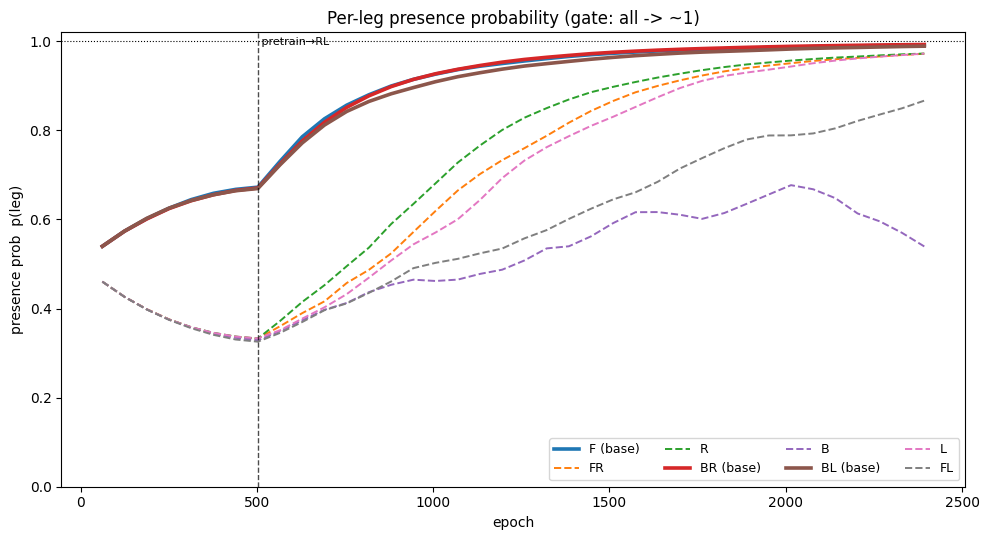

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
cmap = plt.cm.tab10
for i, leg in enumerate(legs):
    base = leg in BASE
    band(ax, f'gen_p/{leg}', color=cmap(i), lw=2.6 if base else 1.4,
         ls='-' if base else '--', label=f"{leg}{' (base)' if base else ''}")
ax.axhline(1.0, color='k', lw=0.8, ls=':')
ax.set(xlabel='epoch', ylabel='presence prob  p(leg)', ylim=(0, 1.02),
       title='Per-leg presence probability (gate: all -> ~1)')
mark_rl(ax)
ax.legend(ncol=4, fontsize=9); fig.tight_layout()

## 2. Mean leg count

`gen/mean_legcount` = E[#legs] under the generator's p; `built/mean_legcount` = the bodies actually
built (includes the pretrain base±flip ramp). Both should climb base(~3) -> ~8.

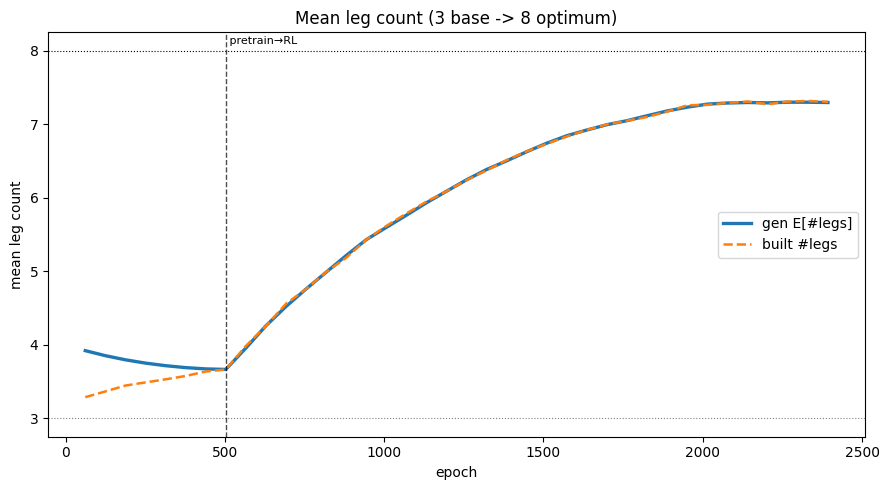

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
band(ax, 'gen/mean_legcount', color='C0', lw=2.4, label='gen E[#legs]')
band(ax, 'built/mean_legcount', color='C1', lw=1.8, ls='--', label='built #legs')
ax.axhline(8, color='k', lw=0.8, ls=':'); ax.axhline(3, color='gray', lw=0.8, ls=':')
ax.set(xlabel='epoch', ylabel='mean leg count', title='Mean leg count (3 base -> 8 optimum)')
mark_rl(ax)
ax.legend(); fig.tight_layout()

## 3. Control performance (training, all bodies)

`morph_reward/mean` = mean shaped reward/step across the bodies sampled each window. Raw curve is
faint; the bold line is a one-resample-window rolling mean, which averages out the per-rebuild dips.

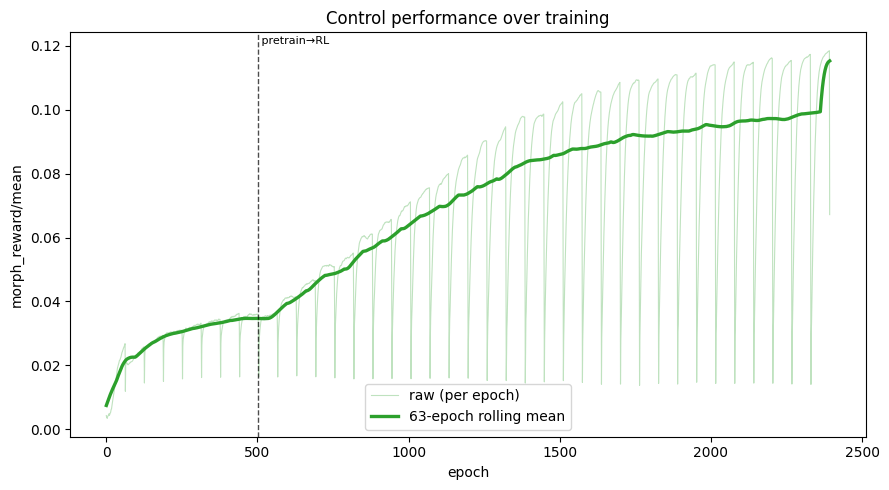

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
band(ax, 'morph_reward/mean', color='C2', lw=0.8, alpha=0.3, label='raw (per epoch)')
band(ax, 'morph_reward/mean', color='C2', lw=2.4, smooth_w=WINDOW_EPOCHS,
     label=f'{WINDOW_EPOCHS}-epoch rolling mean')
ax.set(xlabel='epoch', ylabel='morph_reward/mean', title='Control performance over training')
mark_rl(ax)
ax.legend(); fig.tight_layout()

## 4. Generator value baseline + entropy

`gen/value` is the scalar return baseline (advantage-normalized, so it lags — diagnostic). `gen/entropy`
is the summed Bernoulli entropy; a gentle decline (not a cliff) means no premature collapse.

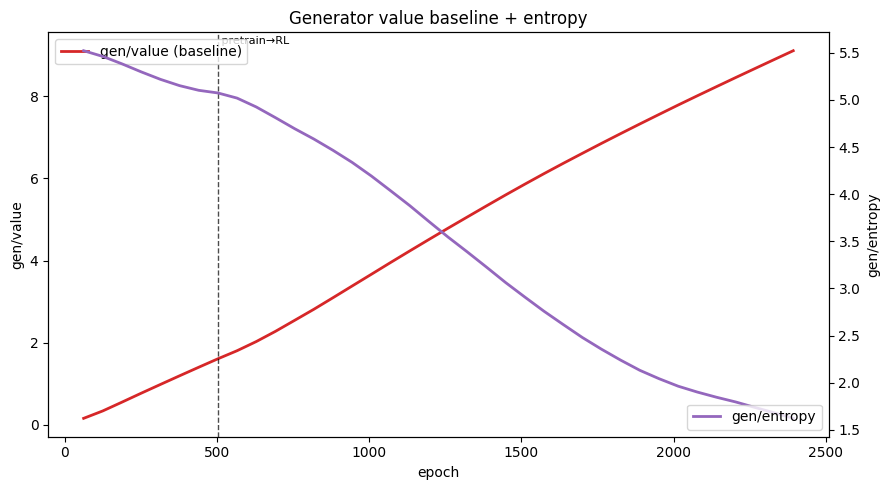

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
band(ax, 'gen/value', color='C3', lw=2.0, label='gen/value (baseline)')
ax.set(xlabel='epoch', ylabel='gen/value'); ax.legend(loc='upper left')
ax2 = ax.twinx()
band(ax2, 'gen/entropy', color='C4', lw=2.0, label='gen/entropy')
ax2.set_ylabel('gen/entropy'); ax2.legend(loc='lower right')
mark_rl(ax)
ax.set_title('Generator value baseline + entropy'); fig.tight_layout()

## 5. Control performance on the BASE morphology

Offline per-checkpoint eval (deterministic mu, raw episode return) on the FIXED base body — isolates
control skill on one body, decoupled from the changing generated bodies. **Rising/flat = base skill
retained; falling = the policy forgets base as it specializes on leggier generated bodies.**

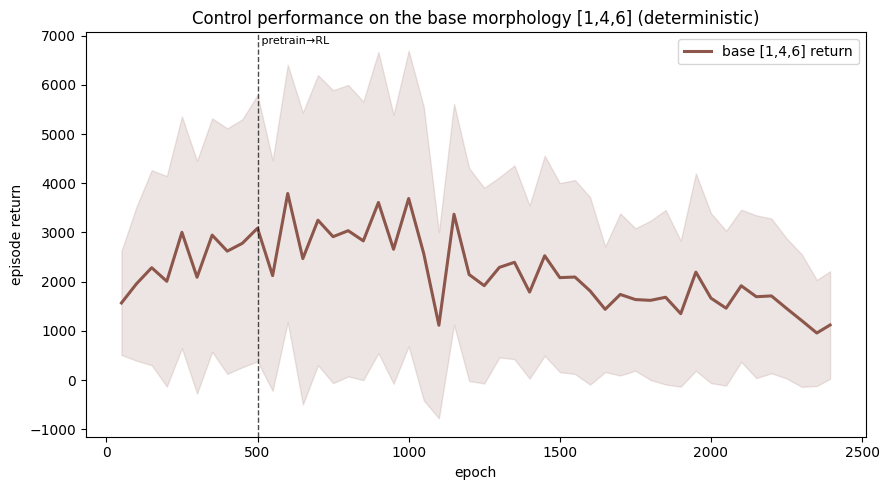

In [11]:
B = np.load(Path('../data/ant_codesign/base_eval.npz'))
base_lbl = '[' + ','.join(str(int(x)) for x in B['base_legs']) + ']'
fig, ax = plt.subplots(figsize=(9, 5))
for i, s in enumerate(seeds):
    ep, mu, sd = B[f's{s}__epoch'], B[f's{s}__ret_mean'], B[f's{s}__ret_std']
    ax.plot(ep, mu, color='C5', lw=2.2, label=f'base {base_lbl} return' if i == 0 else None)
    ax.fill_between(ep, mu - sd, mu + sd, color='C5', alpha=0.15)
ax.set(xlabel='epoch', ylabel='episode return',
       title=f'Control performance on the base morphology {base_lbl} (deterministic)')
mark_rl(ax)
ax.legend(); fig.tight_layout()